<b><font color="#1f4e79" size="7">
Notebook 4:
<br></font></b>

<b><font color="#1f4e79" size="6">
Classification & Comparison
</font></b>

<hr>

This notebook implements a complete pipeline for:

- Loading the connectivity feature matrices generated in Notebook 2.
- Evaluating the **original connectivity features** together with the three feature selection and dimensionality reduction methods introduced in Notebook 3:
  - **ANOVA (F-test)** feature selection.
  - **LASSO (L1 regularization)** feature selection.
  - **Principal Component Analysis (PCA)**.
- Training three classical machine learning classifiers:
  - **Support Vector Machine (SVM)**
  - **K-Nearest Neighbors (KNN)**
  - **Random Forest (RF)**
- Performing model selection using **stratified cross-validation** and hyperparameter optimization.
- Comparing the performance of all **24 classification configurations** combining connectivity type, feature representation, and classifier using standard evaluation metrics.

# Setup

## Install & Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, f1_score,

## Download Input Data

This section downloads all files required for machine learning classification:

- Pearson connectivity feature matrix generated in **Notebook 2**.
- Partial connectivity feature matrix generated in **Notebook 2**.
- Participant labels generated in **Notebook 3** (`participants_with_labels.csv`).

In [2]:
# Pearson feature matrix
!wget -O /content/X_pearson.npy \
"https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook2/X_pearson.npy"

# Partial feature matrix
!wget -O /content/X_partial.npy \
"https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook2/X_partial.npy"

# Participant labels
!wget -O /content/participants_with_labels.csv \
"https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook3/participants_with_labels.csv"

--2026-08-06 20:50:52--  https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook2/X_pearson.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7888448 (7.5M) [application/octet-stream]
Saving to: ‘/content/X_pearson.npy’

/content/X_pearson. 100%[===================>]   7.52M  --.-KB/s    in 0.08s   

2026-08-06 20:50:53 (94.3 MB/s) - ‘/content/X_pearson.npy’ saved [7888448/7888448]

--2026-08-06 20:50:53--  https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook2/X_partial.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
H

## Load Features and Labels

The connectivity feature matrices are loaded, and the binary class labels are extracted from the participant metadata.

In [3]:
X_pearson = np.load("/content/X_pearson.npy")

X_partial = np.load("/content/X_partial.npy")

participants = pd.read_csv("/content/participants_with_labels.csv")
y = participants["label"].values

print("Pearson features:", X_pearson.shape)
print("Partial features:", X_partial.shape)

print("\nLabels:", y.shape)
print("Class distribution: \n", pd.Series(y).value_counts())

Pearson features: (72, 13695)
Partial features: (72, 13695)

Labels: (72,)
Class distribution: 
 1    51
0    21
Name: count, dtype: int64


# Machine Learning Pipeline


In [4]:
RANDOM_STATE = 42

In [5]:
results = []

## Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised machine learning algorithm widely used for binary classification. Its objective is to find the optimal decision boundary (hyperplane) that maximizes the margin between the two classes. Depending on the selected kernel, SVM can model both linear and non-linear decision boundaries.

The function below performs the complete SVM classification pipeline. It accepts two inputs:

- **`connectivity`**: Functional connectivity representation (`"pearson"` or `"partial"`).
- **`feature_type`**: Feature representation (`"original"`, `"anova"`, `"lasso"`, or `"pca"`).

For each configuration, the function:

- Loads the selected functional connectivity features.
- Builds the corresponding preprocessing and feature-selection pipeline.
- Optimizes the SVM hyperparameters using **GridSearchCV** with **10-fold Stratified Cross-Validation**.
- Generates cross-validated predictions using the best model.
- Computes the evaluation metrics:
  - Accuracy
  - Balanced Accuracy
  - Sensitivity (Recall)
  - Specificity
  - F1-score
- Stores the trained model, optimal hyperparameters, selected features (when applicable), and evaluation results for later comparison and visualization.

In [6]:
def run_svm(connectivity, feature_type):

    if connectivity == "pearson":
        X = X_pearson
    elif connectivity == "partial":
        X = X_partial
    else:
        raise ValueError("Connectivity must be 'pearson' or 'partial'")

    cv = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    if feature_type == "original":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE))
        ])

        params = {
            "svm__kernel": ["linear", "rbf"],
            "svm__C": [0.001, 0.01, 0.1, 1],
            "svm__gamma": ["scale", "auto"]
        }


    elif feature_type == "anova":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("feature", SelectKBest(score_func=f_classif)),
            ("svm", SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE))
        ])

        params = {
            "feature__k": [70, 100, 150],
            "svm__kernel": ["linear", "rbf"],
            "svm__C": [0.001, 0.01, 0.1, 1],
            "svm__gamma": ["scale", "auto"]
        }


    elif feature_type == "lasso":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("feature", SelectFromModel(LogisticRegression(penalty="l1", solver="liblinear", random_state=RANDOM_STATE))),
            ("svm", SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE))
        ])

        params = {
            "feature__estimator__C": [1, 5, 10],
            "svm__kernel": ["linear", "rbf"],
            "svm__C": [0.001, 0.1, 1],
            "svm__gamma": ["scale", "auto"]
        }


    elif feature_type == "pca":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(random_state=RANDOM_STATE)),
            ("svm", SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE))
        ])

        params = {
            "pca__n_components": [0.80, 0.90, 0.95],
            "svm__kernel": ["linear", "rbf"],
            "svm__C": [0.1, 1, 0.5],
            "svm__gamma": ["scale", "auto"]
        }


    else:
        raise ValueError("feature_type must be 'original', 'anova', 'lasso' or 'pca'")


    grid = GridSearchCV(
        pipeline,
        params,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1
    )

    grid.fit(X, y)

    y_pred = cross_val_predict(
        grid.best_estimator_,
        X,
        y,
        cv=cv,
        method="predict",
        n_jobs=-1
    )


    result = {
        "name": f"{connectivity}_{feature_type}_svm",
        "connectivity": connectivity,
        "feature_type": feature_type,
        "classifier": "SVM",
        "best_params": grid.best_params_,
        "cv_accuracy": grid.best_score_,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "sensitivity": recall_score(y, y_pred),
        "specificity": recall_score(y, y_pred, pos_label=0),
        "f1": f1_score(y, y_pred),
        "model": grid.best_estimator_,
    }


    if feature_type == "anova":

        selector = grid.best_estimator_.named_steps["feature"]

        result["selected_features"] = selector.get_support(indices=True)
        result["feature_scores"] = selector.scores_


    elif feature_type == "lasso":

        selector = grid.best_estimator_.named_steps["feature"]

        result["selected_features"] = selector.get_support(indices=True)
        result["feature_scores"] = selector.estimator_.coef_.ravel()


    elif feature_type == "original":

        svm = grid.best_estimator_.named_steps["svm"]

        if grid.best_params_["svm__kernel"] == "linear":
            result["feature_scores"] = svm.coef_.ravel()

    results.append(result)

    print("=" * 60)
    print(result["name"])
    print(f"Best params: {result['best_params']}")

    if feature_type in ["anova", "lasso"]:
        print(f"Selected features: {len(result['selected_features'])}")

    print(f"CV Balanced Accuracy: {result['cv_accuracy']:.3f}")
    print(f"Accuracy: {result['accuracy']:.3f}")
    print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
    print(f"Sensitivity: {result['sensitivity']:.3f}")
    print(f"Specificity: {result['specificity']:.3f}")
    print(f"F1: {result['f1']:.3f}")
    print("=" * 60)

In [7]:
for conn in ["pearson", "partial"]:
    for feat in ["original", "anova", "lasso", "pca"]:
        run_svm(conn, feat)

pearson_original_svm
Best params: {'svm__C': 0.001, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
CV Balanced Accuracy: 0.518
Accuracy: 0.667
Balanced Accuracy: 0.513
Sensitivity: 0.882
Specificity: 0.143
F1: 0.789
pearson_anova_svm
Best params: {'feature__k': 100, 'svm__C': 0.01, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Selected features: 100
CV Balanced Accuracy: 0.618
Accuracy: 0.736
Balanced Accuracy: 0.618
Sensitivity: 0.902
Specificity: 0.333
F1: 0.829
pearson_lasso_svm
Best params: {'feature__estimator__C': 1, 'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Selected features: 51
CV Balanced Accuracy: 0.673
Accuracy: 0.750
Balanced Accuracy: 0.669
Sensitivity: 0.863
Specificity: 0.476
F1: 0.830
pearson_pca_svm
Best params: {'pca__n_components': 0.8, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
CV Balanced Accuracy: 0.698
Accuracy: 0.583
Balanced Accuracy: 0.692
Sensitivity: 0.431
Specificity: 0.952
F1: 0.595
partial_original_svm
Best params: {

## K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised, non-parametric machine learning algorithm that classifies a sample based on the labels of its *k* nearest neighbors in the feature space. The predicted class is determined by majority voting among these neighboring samples. Because KNN is distance-based, feature scaling is essential to ensure that all features contribute equally to the distance calculation.

The function below follows the same evaluation framework as the SVM pipeline. It accepts two inputs:

- **`connectivity`**: Functional connectivity representation (`"pearson"` or `"partial"`).
- **`feature_type`**: Feature representation (`"original"`, `"anova"`, `"lasso"`, or `"pca"`).

For each configuration, the function:

- Loads the selected functional connectivity features.
- Builds the corresponding preprocessing and feature-selection pipeline.
- Optimizes the KNN hyperparameters using **GridSearchCV** with **10-fold Stratified Cross-Validation**.
- Generates cross-validated predictions using the best model.
- Computes the evaluation metrics:
  - Accuracy
  - Balanced Accuracy
  - Sensitivity
  - Specificity
  - F1-score
- Stores the optimal hyperparameters, trained model, selected features (when applicable), and evaluation results for later comparison and visualization.

In [8]:
def run_knn(connectivity, feature_type):

    if connectivity == "pearson":
        X = X_pearson
    elif connectivity == "partial":
        X = X_partial
    else:
        raise ValueError("Connectivity must be 'pearson' or 'partial'")

    cv = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    if feature_type == "original":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier())
        ])

        params = {
            "knn__n_neighbors": [3, 5, 7, 9, 11],
            "knn__weights": ["uniform", "distance"],
            "knn__metric": ["euclidean", "manhattan"]
        }


    elif feature_type == "anova":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("feature", SelectKBest(score_func=f_classif)),
            ("knn", KNeighborsClassifier())
        ])

        params = {
            "feature__k": [30, 50, 100],
            "knn__n_neighbors": [3, 5, 7, 9, 11],
            "knn__weights": ["uniform", "distance"],
            "knn__metric": ["euclidean", "manhattan"]
        }


    elif feature_type == "lasso":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("feature", SelectFromModel(LogisticRegression(penalty="l1", class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE))),
            ("knn", KNeighborsClassifier())
        ])

        params = {
            "feature__estimator__C": [3, 5, 10, 15, 20],
            "knn__n_neighbors": [3, 5, 7, 9, 11],
            "knn__weights": ["uniform", "distance"],
            "knn__metric": ["euclidean", "manhattan"]
        }


    elif feature_type == "pca":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(random_state=RANDOM_STATE)),
            ("knn", KNeighborsClassifier())
        ])

        params = {
            "pca__n_components": [0.80, 0.90, 0.95],
            "knn__n_neighbors": [3, 5, 7, 9, 11],
            "knn__weights": ["uniform", "distance"],
            "knn__metric": ["euclidean", "manhattan"]
        }


    else:
        raise ValueError("feature_type must be 'original', 'anova', 'lasso' or 'pca'")


    grid = GridSearchCV(
        pipeline,
        params,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1
    )

    grid.fit(X, y)


    y_pred = cross_val_predict(
        grid.best_estimator_,
        X,
        y,
        cv=cv,
        method="predict",
        n_jobs=-1
    )


    result = {
        "name": f"{connectivity}_{feature_type}_knn",
        "connectivity": connectivity,
        "feature_type": feature_type,
        "classifier": "KNN",
        "best_params": grid.best_params_,
        "cv_accuracy": grid.best_score_,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "sensitivity": recall_score(y, y_pred),
        "specificity": recall_score(y, y_pred, pos_label=0),
        "f1": f1_score(y, y_pred),
        "model": grid.best_estimator_,
    }


    if feature_type == "anova":

        selector = grid.best_estimator_.named_steps["feature"]

        result["selected_features"] = selector.get_support(indices=True)
        result["feature_scores"] = selector.scores_


    elif feature_type == "lasso":

        selector = grid.best_estimator_.named_steps["feature"]

        result["selected_features"] = selector.get_support(indices=True)
        result["feature_scores"] = selector.estimator_.coef_.ravel()

    results.append(result)

    print("=" * 60)
    print(result["name"])
    print(f"Best params: {result['best_params']}")

    if feature_type in ["anova", "lasso"]:
        print(f"Selected features: {len(result['selected_features'])}")

    print(f"CV Balanced Accuracy: {result['cv_accuracy']:.3f}")
    print(f"Accuracy: {result['accuracy']:.3f}")
    print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
    print(f"Sensitivity: {result['sensitivity']:.3f}")
    print(f"Specificity: {result['specificity']:.3f}")
    print(f"F1: {result['f1']:.3f}")
    print("=" * 60)

In [9]:
for conn in ["pearson", "partial"]:
    for feat in ["original", "anova", "lasso", "pca"]:
        run_knn(conn, feat)

pearson_original_knn
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'uniform'}
CV Balanced Accuracy: 0.570
Accuracy: 0.667
Balanced Accuracy: 0.569
Sensitivity: 0.804
Specificity: 0.333
F1: 0.774
pearson_anova_knn
Best params: {'feature__k': 100, 'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Selected features: 100
CV Balanced Accuracy: 0.627
Accuracy: 0.736
Balanced Accuracy: 0.618
Sensitivity: 0.902
Specificity: 0.333
F1: 0.829
pearson_lasso_knn
Best params: {'feature__estimator__C': 5, 'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Selected features: 78
CV Balanced Accuracy: 0.642
Accuracy: 0.750
Balanced Accuracy: 0.641
Sensitivity: 0.902
Specificity: 0.381
F1: 0.836
pearson_pca_knn
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'uniform', 'pca__n_components': 0.9}
CV Balanced Accuracy: 0.662
Accuracy: 0.736
Balanced Accuracy: 0.660
Sensitivity: 0.843
S

## Random Forest (RF)

Random Forest (RF) is an ensemble learning algorithm that combines multiple decision trees to improve classification performance and reduce overfitting. Each tree is trained on a bootstrap sample of the data while considering a random subset of features at each split. The final prediction is obtained through majority voting across all trees. In addition to classification, Random Forest provides feature importance scores, making it an interpretable model for identifying influential functional connections.

The function below follows the same evaluation framework as the SVM and KNN pipelines. It accepts two inputs:

- **`connectivity`**: Functional connectivity representation (`"pearson"` or `"partial"`).
- **`feature_type`**: Feature representation (`"original"`, `"anova"`, `"lasso"`, or `"pca"`).

For each configuration, the function:

- Loads the selected functional connectivity features.
- Builds the corresponding preprocessing and feature-selection pipeline.
- Optimizes the Random Forest hyperparameters using **GridSearchCV** with **10-fold Stratified Cross-Validation**.
- Generates cross-validated predictions using the best model.
- Computes the evaluation metrics:
  - Accuracy
  - Balanced Accuracy
  - Sensitivity
  - Specificity
  - F1-score
- Stores the optimal hyperparameters, trained model, selected features (when applicable), feature importance scores, and evaluation results for later comparison and visualization.


In [10]:
def run_rf(connectivity, feature_type):

    if connectivity == "pearson":
        X = X_pearson
    elif connectivity == "partial":
        X = X_partial
    else:
        raise ValueError("Connectivity must be 'pearson' or 'partial'")

    cv = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    if feature_type == "original":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("rf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))
        ])

        params = {
            "rf__n_estimators": [100, 200],
            "rf__max_depth": [None, 5],
            "rf__min_samples_split": [2, 3],
            "rf__min_samples_leaf": [1, 2]
        }


    elif feature_type == "anova":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("feature", SelectKBest(score_func=f_classif)),
            ("rf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))
        ])

        params = {
            "feature__k": [30, 50, 100],
            "rf__n_estimators": [100, 200],
            "rf__max_depth": [None, 5],
            "rf__min_samples_split": [2, 3],
            "rf__min_samples_leaf": [1, 2]
        }


    elif feature_type == "lasso":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("feature", SelectFromModel(LogisticRegression(penalty="l1", class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE))),
            ("rf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))
        ])

        params = {
            "feature__estimator__C": [5, 10, 15],
            "rf__n_estimators": [100, 200],
            "rf__max_depth": [None, 5],
            "rf__min_samples_split": [2, 3],
            "rf__min_samples_leaf": [2, 1]
        }


    elif feature_type == "pca":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(random_state=RANDOM_STATE)),
            ("rf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))
        ])

        params = {
            "pca__n_components": [0.80, 0.90],
            "rf__n_estimators": [100, 200],
            "rf__max_depth": [None, 5],
            "rf__min_samples_split": [2, 3],
            "rf__min_samples_leaf": [1, 2]
        }


    else:
        raise ValueError("feature_type must be 'original', 'anova', 'lasso' or 'pca'")


    grid = GridSearchCV(
        pipeline,
        params,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1
    )

    grid.fit(X, y)

    y_pred = cross_val_predict(
        grid.best_estimator_,
        X,
        y,
        cv=cv,
        method="predict",
        n_jobs=-1
    )


    result = {
        "name": f"{connectivity}_{feature_type}_rf",
        "connectivity": connectivity,
        "feature_type": feature_type,
        "classifier": "RF",
        "best_params": grid.best_params_,
        "cv_accuracy": grid.best_score_,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "sensitivity": recall_score(y, y_pred),
        "specificity": recall_score(y, y_pred, pos_label=0),
        "f1": f1_score(y, y_pred),
        "model": grid.best_estimator_,
    }


    if feature_type == "anova":

        selector = grid.best_estimator_.named_steps["feature"]

        result["selected_features"] = selector.get_support(indices=True)
        result["feature_scores"] = selector.scores_


    elif feature_type == "lasso":

        selector = grid.best_estimator_.named_steps["feature"]

        result["selected_features"] = selector.get_support(indices=True)
        result["feature_scores"] = selector.estimator_.coef_.ravel()


    elif feature_type == "original":

        rf = grid.best_estimator_.named_steps["rf"]
        result["feature_scores"] = rf.feature_importances_

    results.append(result)

    print("=" * 60)
    print(result["name"])
    print(f"Best params: {result['best_params']}")

    if feature_type in ["anova", "lasso"]:
        print(f"Selected features: {len(result['selected_features'])}")

    print(f"CV Balanced Accuracy: {result['cv_accuracy']:.3f}")
    print(f"Accuracy: {result['accuracy']:.3f}")
    print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
    print(f"Sensitivity: {result['sensitivity']:.3f}")
    print(f"Specificity: {result['specificity']:.3f}")
    print(f"F1: {result['f1']:.3f}")
    print("=" * 60)

In [11]:
for conn in ["pearson", "partial"]:
    for feat in ["original", "anova", "lasso", "pca"]:
        run_rf(conn, feat)

pearson_original_rf
Best params: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
CV Balanced Accuracy: 0.500
Accuracy: 0.708
Balanced Accuracy: 0.500
Sensitivity: 1.000
Specificity: 0.000
F1: 0.829
pearson_anova_rf
Best params: {'feature__k': 30, 'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Selected features: 30
CV Balanced Accuracy: 0.650
Accuracy: 0.792
Balanced Accuracy: 0.643
Sensitivity: 1.000
Specificity: 0.286
F1: 0.872
pearson_lasso_rf
Best params: {'feature__estimator__C': 5, 'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 3, 'rf__n_estimators': 100}
Selected features: 78
CV Balanced Accuracy: 0.575
Accuracy: 0.750
Balanced Accuracy: 0.571
Sensitivity: 1.000
Specificity: 0.143
F1: 0.850
pearson_pca_rf
Best params: {'pca__n_components': 0.8, 'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 3, 'rf__n_estimators': 100}

## Model Comparison

After evaluating all combinations of classifiers, feature representations, and functional connectivity measures, the results are collected into a single summary table. This table reports the performance of every experiment using the following metrics:

- **Balanced Accuracy** (primary evaluation metric)
- Accuracy
- Sensitivity
- Specificity
- F1-score

The experiments are sorted in descending order of **Balanced Accuracy**, making it straightforward to identify the best-performing models before performing further interpretation and visualization.

In [12]:
results_df = pd.DataFrame(results)

display(
    results_df[[
        "name",
        "classifier",
        "feature_type",
        "connectivity",
        "balanced_accuracy",
        "accuracy",
        "sensitivity",
        "specificity",
        "f1"
    ]].sort_values("balanced_accuracy", ascending=False)
)

,name,classifier,feature_type,connectivity,balanced_accuracy,accuracy,sensitivity,specificity,f1
3,pearson_pca_svm,SVM,pca,pearson,0.691877,0.583333,0.431373,0.952381,0.594595
2,pearson_lasso_svm,SVM,lasso,pearson,0.669468,0.750000,0.862745,0.476190,0.830189
11,pearson_pca_knn,KNN,pca,pearson,0.659664,0.736111,0.843137,0.476190,0.819048
17,pearson_anova_rf,RF,anova,pearson,0.642857,0.791667,1.000000,0.285714,0.871795
10,pearson_lasso_knn,KNN,lasso,pearson,0.641457,0.750000,0.901961,0.380952,0.836364
9,pearson_anova_knn,KNN,anova,pearson,0.617647,0.736111,0.901961,0.333333,0.828829
1,pearson_anova_svm,SVM,anova,pearson,0.617647,0.736111,0.901961,0.333333,0.828829
6,partial_lasso_svm,SVM,lasso,partial,0.599440,0.750000,0.960784,0.238095,0.844828
19,pearson_pca_rf,RF,pca,pearson,0.599440,0.750000,0.960784,0.238095,0.844828
7,partial_pca_svm,SVM,pca,partial,0.578431,0.680556,0.823529,0.333333,0.785047


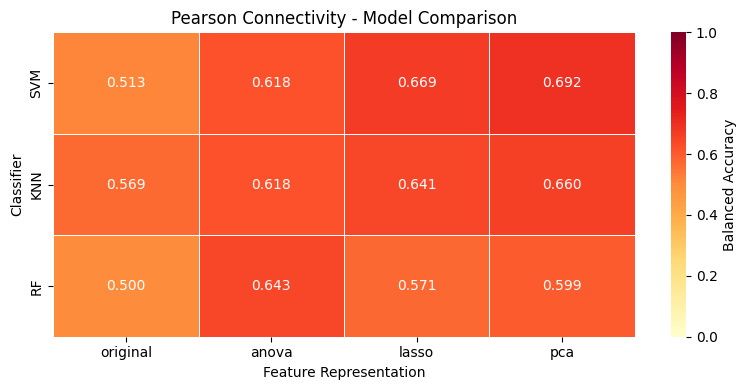

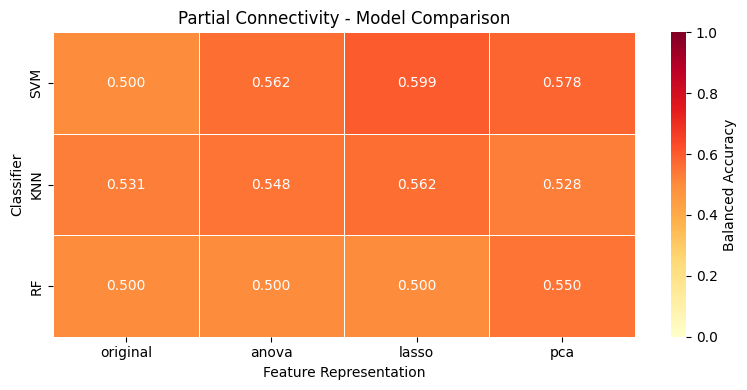

In [13]:
feature_order = ["original", "anova", "lasso", "pca"]

classifier_order = ["SVM", "KNN", "RF"]

def plot_model_heatmap(connectivity):

    df = results_df[results_df["connectivity"] == connectivity]

    heatmap_data = df.pivot(
        index="classifier",
        columns="feature_type",
        values="balanced_accuracy"
    )

    heatmap_data = heatmap_data.loc[
        classifier_order,
        feature_order
    ]

    plt.figure(figsize=(8, 4))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        cbar_kws={"label": "Balanced Accuracy"}
    )

    plt.title(f"{connectivity.capitalize()} Connectivity - Model Comparison")
    plt.xlabel("Feature Representation")
    plt.ylabel("Classifier")

    plt.tight_layout()
    plt.show()


plot_model_heatmap("pearson")
plot_model_heatmap("partial")

## Overall Performance Analysis

To better understand the contribution of each component in the machine learning pipeline, the average **Balanced Accuracy** is calculated across different categories:

- **Connectivity type**
- **Feature representation**
- **Classifier**

In [14]:
print("Best Overall Components")
print("="*50)

print("\n", results_df.groupby("connectivity")["balanced_accuracy"].mean().sort_values(ascending=False))

print("\n", results_df.groupby("feature_type")["balanced_accuracy"].mean().sort_values(ascending=False))

print("\n", results_df.groupby("classifier")["balanced_accuracy"].mean().sort_values(ascending=False))

Best Overall Components

 connectivity
pearson    0.607726
partial    0.538165
Name: balanced_accuracy, dtype: float64

 feature_type
pca         0.601307
lasso       0.590570
anova       0.581232
original    0.518674
Name: balanced_accuracy, dtype: float64

 classifier
SVM    0.591387
KNN    0.581933
RF     0.545518
Name: balanced_accuracy, dtype: float64
